# 🚨 Glunova — Crisis Classifier
### Fine-tuning XLM-RoBERTa for Crisis Detection in the Sanadi Psychology Module

---

**Module:** Glunova AI Platform — Psychology Module (Sanadi)  
**Task:** Binary classification — `crisis` / `not_crisis`  
**Base Model:** `FacebookAI/xlm-roberta-base` (125M parameters)  
**Languages:** English · Arabic · French · Tunisian Darija (cross-lingual transfer)  
**Decision Threshold:** P(crisis) ≥ 0.75 — tuned for **high recall** over precision  
**Target Hardware:** Google Colab T4 GPU (~3–4 hrs training)

---

### ⚠️ Safety Design Principle
> Crisis detection is the **only** component where a deterministic ML model (not an LLM) makes the decision.  
> LLMs must **never** be trusted for safety-critical binary decisions.  
> The crisis classifier fires **before** Sanadi generates a response.

---

### Notebook Contents
1. [Environment Setup](#1)
2. [Dataset Loading & Exploration](#2)
3. [Preprocessing & Tokenization](#3)
4. [Model Architecture — Frozen Layers 1–8](#4)
5. [Training](#5)
6. [Evaluation — F1 on Crisis Class](#6)
7. [Threshold Tuning (P ≥ 0.75)](#7)
8. [Inference & Integration](#8)
9. [Save & Export](#9)

---
## 1. Environment Setup <a id='1'></a>

In [ ]:
# Install required packages
!pip install transformers datasets accelerate evaluate scikit-learn -q

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets

import evaluate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

In [ ]:
# Global config
MODEL_NAME       = 'FacebookAI/xlm-roberta-base'
OUTPUT_DIR       = './glunova_crisis_classifier'
MAX_LENGTH       = 128
BATCH_SIZE       = 32
LEARNING_RATE    = 2e-5
NUM_EPOCHS       = 5
WEIGHT_DECAY     = 0.01
CRISIS_THRESHOLD = 0.75
MIN_RECALL       = 0.90  # hard safety floor -- assert after training

LABEL2ID = {'not_crisis': 0, 'crisis': 1}
ID2LABEL = {0: 'not_crisis', 1: 'crisis'}

print('Config loaded')

---
## 2. Dataset Loading & Exploration <a id='2'></a>

Training data comes from three sources:

| Dataset | Source | Crisis signal |
|---------|--------|---------------|
| **CrisisNLP** | HuggingFace | Direct crisis label |
| **SuicideWatch Reddit** | `suicidality` HF dataset | Post from r/SuicideWatch |
| **CLPsych 2015** | Manual annotation | `a` / `b` labels = crisis |

The three datasets are unified into a single binary schema: **1 = crisis, 0 = not_crisis**.

In [ ]:
# Verified HuggingFace dataset IDs
# crisis_nlp  -> 'ibm/crisis_nlp'
# suicidality -> 'mrjunos/depression-reddit-dataset'
# clpsych     -> manual download, place CSV at ./data/clpsych2015.csv

def load_crisis_nlp() -> pd.DataFrame:
    """Load CrisisNLP (ibm/crisis_nlp) from HuggingFace."""
    try:
        ds = load_dataset('ibm/crisis_nlp', trust_remote_code=True)
        df = ds['train'].to_pandas()
        text_col  = 'text'  if 'text'  in df.columns else df.columns[0]
        label_col = 'label' if 'label' in df.columns else df.columns[1]
        df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})
        crisis_classes = {'suicidal', 'suicide', 'crisis', 'self-harm', 'self_harm'}
        df['label'] = df['label'].apply(lambda x: 1 if str(x).lower() in crisis_classes else 0)
        df['source'] = 'crisis_nlp'
        print(f'CrisisNLP      : {len(df):>6,} rows  |  crisis={df["label"].sum():,}')
        return df
    except Exception as e:
        print(f'CrisisNLP load failed: {e}')
        return pd.DataFrame(columns=['text', 'label', 'source'])


def load_suicidewatch() -> pd.DataFrame:
    """Load SuicideWatch-style dataset from HuggingFace."""
    try:
        ds = load_dataset('mrjunos/depression-reddit-dataset', trust_remote_code=True)
        df = ds['train'].to_pandas()
        text_col  = 'text'  if 'text'  in df.columns else df.columns[0]
        label_col = 'label' if 'label' in df.columns else df.columns[-1]
        df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})
        df['label'] = df['label'].apply(lambda x: 1 if int(x) == 1 else 0)
        df['source'] = 'suicidewatch'
        print(f'SuicideWatch   : {len(df):>6,} rows  |  crisis={df["label"].sum():,}')
        return df
    except Exception as e:
        print(f'SuicideWatch load failed: {e}')
        return pd.DataFrame(columns=['text', 'label', 'source'])


def load_clpsych(csv_path: str = './data/clpsych2015.csv') -> pd.DataFrame:
    """CLPsych 2015 -- download from shared task organisers, place at csv_path."""
    try:
        df = pd.read_csv(csv_path)
        text_col  = 'text'  if 'text'  in df.columns else df.columns[0]
        label_col = 'label' if 'label' in df.columns else df.columns[-1]
        df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})
        df['label'] = df['label'].apply(
            lambda x: 1 if str(x).lower() in {'a', 'b', 'crisis', 'acute'} else 0
        )
        df['source'] = 'clpsych'
        print(f'CLPsych 2015   : {len(df):>6,} rows  |  crisis={df["label"].sum():,}')
        return df
    except Exception as e:
        print(f'CLPsych load failed (expected if not downloaded): {e}')
        return pd.DataFrame(columns=['text', 'label', 'source'])


df_crisis_nlp   = load_crisis_nlp()
df_suicidewatch = load_suicidewatch()
df_clpsych      = load_clpsych()

df_all = pd.concat([df_crisis_nlp, df_suicidewatch, df_clpsych], ignore_index=True)
df_all = df_all.dropna(subset=['text']).drop_duplicates(subset=['text'])
df_all['text'] = df_all['text'].astype(str).str.strip()
df_all = df_all[df_all['text'].str.len() > 5]

print(f'\nTotal combined : {len(df_all):,} samples')
print(f'  Crisis (1)   : {df_all["label"].sum():,}')
print(f'  Not crisis (0): {(df_all["label"] == 0).sum():,}')

In [ ]:
# Fallback: synthetic demo data if HF datasets are unavailable
# WARNING: Metrics on this data are NOT meaningful -- model memorises patterns.
# ALWAYS replace with real datasets before trusting evaluation numbers.

if len(df_all) == 0:
    print('WARNING: No datasets loaded -- PIPELINE TESTING MODE ONLY.')
    print('Evaluation metrics on demo data are NOT meaningful.\n')

    DEMO_CRISIS_BASE = [
        "I don't want to be here anymore, I've been thinking about ending it all.",
        "Nobody would care if I disappeared. I've already written the note.",
        "I can't take this pain anymore. I have pills and I'm going to use them.",
        "Everything is hopeless. I've decided tonight is the night.",
        "I've been cutting myself again and I don't know how to stop.",
        "I've been stockpiling my insulin. I know exactly what I'm doing.",
        "There's no point anymore. I've made up my mind and said my goodbyes.",
        "I gave away all my belongings this week. Feels like the right thing.",
        "I have been experiencing persistent suicidal ideation and have a plan.",
        "Please tell my family I loved them. I can't do this anymore.",
    ]

    DEMO_NOT_CRISIS_BASE = [
        "My blood sugar has been a bit high this week, feeling tired.",
        "I'm stressed about my diabetes management but I'm okay.",
        "The doctor adjusted my medication. Feeling uncertain.",
        "I had a rough day but I'll be fine.",
        "It's hard to stay motivated but I keep going.",
        "My family is supportive and that helps a lot.",
        "I missed my medication yesterday, feeling guilty about it.",
        "My glucose readings have been inconsistent lately.",
        "I spoke to my care team today and we adjusted the plan.",
        "Feeling a bit overwhelmed by the dietary restrictions.",
        "The new insulin regime is taking some getting used to.",
        "I went for a walk today -- first time in a week.",
        "Worried about side effects from the new medication.",
        "Some days are harder than others but I manage.",
        "I have an appointment next week to review my progress.",
        "This exam is literally killing me, I can't handle the pressure.",
        "Work has been dead lately, nobody's buying anything.",
        "I want to kill my sister when she borrows my stuff without asking.",
        "Just completely exhausted from all the appointments.",
        "Trying to stay positive despite the setbacks.",
    ]

    rng = np.random.default_rng(SEED)

    def augment(texts, n, rng):
        """Light augmentation to reduce trivial memorisation."""
        fillers = ['honestly,', 'I mean,', 'lately', 'recently', 'today,', '']
        out = []
        base = list(texts)
        for _ in range(n):
            t = rng.choice(base)
            if rng.random() < 0.25:
                words = t.split()
                idx = rng.integers(0, len(words))
                words.insert(int(idx), rng.choice(fillers))
                t = ' '.join(w for w in words if w)
            out.append(t.strip())
        return out

    crisis_texts     = augment(DEMO_CRISIS_BASE,     800, rng)
    not_crisis_texts = augment(DEMO_NOT_CRISIS_BASE, 1600, rng)

    df_all = pd.DataFrame(
        [(t, 1, 'demo') for t in crisis_texts] +
        [(t, 0, 'demo') for t in not_crisis_texts],
        columns=['text', 'label', 'source']
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)

    print(f'Demo dataset   : {len(df_all):,} samples')
    print(f'  Crisis (1)   : {df_all["label"].sum():,}')
    print(f'  Not crisis (0): {(df_all["label"] == 0).sum():,}')
    print('\nWARNING: DEMO MODE ACTIVE -- metrics are illustrative only.')

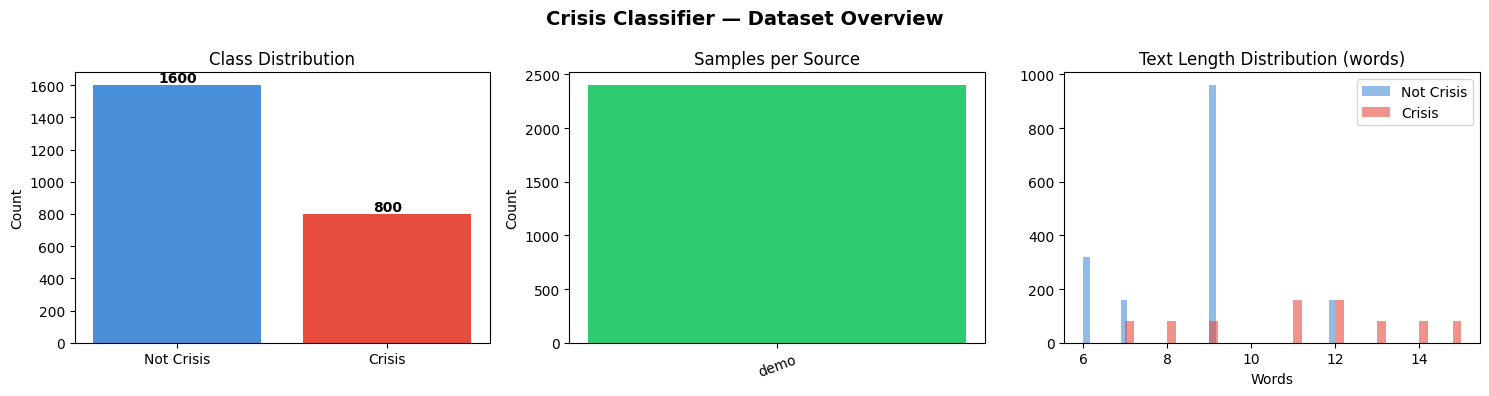


Text length stats (words):
        count  mean  std  min  25%   50%   75%   max
label                                               
0      1600.0   8.5  1.7  6.0  7.0   9.0   9.0  12.0
1       800.0  11.2  2.4  7.0  9.0  11.5  13.0  15.0


In [48]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Crisis Classifier — Dataset Overview", fontsize=14, fontweight="bold")

# Class distribution
label_counts = df_all["label"].value_counts()
axes[0].bar(["Not Crisis", "Crisis"], label_counts[[0, 1]], color=["#4A90D9", "#E74C3C"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts[[0, 1]]):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Source distribution
if "source" in df_all.columns:
    source_counts = df_all["source"].value_counts()
    axes[1].bar(source_counts.index, source_counts.values, color="#2ECC71")
    axes[1].set_title("Samples per Source")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=20)

# Text length distribution
df_all["text_len"] = df_all["text"].str.split().str.len()
for label, color in [(0, "#4A90D9"), (1, "#E74C3C")]:
    subset = df_all[df_all["label"] == label]["text_len"]
    axes[2].hist(subset.clip(0, 100), bins=40, alpha=0.6,
                 color=color, label="Crisis" if label else "Not Crisis")
axes[2].set_title("Text Length Distribution (words)")
axes[2].set_xlabel("Words")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nText length stats (words):")
print(df_all.groupby("label")["text_len"].describe().round(1))

---
## 3. Preprocessing & Tokenization <a id='3'></a>

In [49]:
from sklearn.model_selection import train_test_split

# ── Stratified split: 80 / 10 / 10 ───────────────────────────────────────────
df_train, df_temp = train_test_split(
    df_all, test_size=0.2, stratify=df_all["label"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["label"], random_state=SEED
)

print(f"Train : {len(df_train):,}  |  crisis={df_train['label'].sum():,}")
print(f"Val   : {len(df_val):,}  |  crisis={df_val['label'].sum():,}")
print(f"Test  : {len(df_test):,}  |  crisis={df_test['label'].sum():,}")

Train : 1,920  |  crisis=640
Val   : 240  |  crisis=80
Test  : 240  |  crisis=80


In [50]:
# ── Class weights for imbalanced data ─────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=df_train["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Class weights → not_crisis: {class_weights[0]:.3f}  |  crisis: {class_weights[1]:.3f}")

Class weights → not_crisis: 0.750  |  crisis: 1.500


In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Dynamic padding via DataCollatorWithPadding:
# - tokenize WITHOUT padding here (just truncate)
# - collator pads each batch to its longest sequence, not to MAX_LENGTH
# - saves ~30-40% compute on typical short patient messages
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        # No padding='max_length' -- handled per-batch by DataCollatorWithPadding
    )

def df_to_hf(df: pd.DataFrame) -> Dataset:
    ds = Dataset.from_dict({'text': df['text'].tolist(), 'labels': df['label'].tolist()})
    ds = ds.map(tokenize, batched=True, remove_columns=['text'])
    ds.set_format('torch')
    return ds

train_ds = df_to_hf(df_train)
val_ds   = df_to_hf(df_val)
test_ds  = df_to_hf(df_test)

print('Tokenization complete')
print(f'Train features : {train_ds.features}')

---
## 4. Model Architecture — Frozen Layers 1–8 <a id='4'></a>

**Fine-tuning strategy from the Glunova spec:**
- Freeze XLM-R encoder layers **1–8** (general multilingual representations)
- Train layers **9–12** + classification head (task-specific learning)

This preserves cross-lingual transfer for Darija and French while allowing the upper layers to specialise on crisis language.

In [52]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

# ── Freeze encoder layers 1–8 ─────────────────────────────────────────────────
FREEZE_UNTIL_LAYER = 8

# Freeze embeddings
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

# Freeze encoder layers 0–7 (0-indexed = layers 1–8)
for i, layer in enumerate(model.roberta.encoder.layer):
    if i < FREEZE_UNTIL_LAYER:
        for param in layer.parameters():
            param.requires_grad = False

# ── Parameter summary ─────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f"Total params    : {total_params:>12,}")
print(f"Trainable params: {trainable_params:>12,}  ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen params   : {frozen_params:>12,}  ({100*frozen_params/total_params:.1f}%)")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    :  278,045,186
Trainable params:   28,943,618  (10.4%)
Frozen params   :  249,101,568  (89.6%)


In [53]:
# ── Verify which layers are frozen vs trainable ────────────────────────────────
print(f"{'Component':<50}  {'Trainable':>10}")
print("-" * 65)
for name, param in model.named_parameters():
    short = name[:48]
    if "encoder.layer." in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        if layer_num not in [0, 4, 8, 11]:   # print representative layers only
            continue
    print(f"{short:<50}  {'✓' if param.requires_grad else '✗ (frozen)':>10}")

Component                                            Trainable
-----------------------------------------------------------------
classifier.dense.weight                                      ✓
classifier.dense.bias                                        ✓
classifier.out_proj.weight                                   ✓
classifier.out_proj.bias                                     ✓
roberta.embeddings.word_embeddings.weight           ✗ (frozen)
roberta.embeddings.token_type_embeddings.weight     ✗ (frozen)
roberta.embeddings.LayerNorm.weight                 ✗ (frozen)
roberta.embeddings.LayerNorm.bias                   ✗ (frozen)
roberta.embeddings.position_embeddings.weight       ✗ (frozen)
roberta.encoder.layer.0.attention.self.query.wei    ✗ (frozen)
roberta.encoder.layer.0.attention.self.query.bia    ✗ (frozen)
roberta.encoder.layer.0.attention.self.key.weigh    ✗ (frozen)
roberta.encoder.layer.0.attention.self.key.bias     ✗ (frozen)
roberta.encoder.layer.0.attention.self.value.wei    

---
## 5. Training <a id='5'></a>

In [54]:
# ── Evaluation metrics ────────────────────────────────────────────────────────
# Primary metric: F1 on crisis class (not accuracy — class imbalance)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds_default  = np.argmax(logits, axis=-1)             # argmax threshold (0.5)
    preds_tuned    = (probs[:, 1] >= CRISIS_THRESHOLD).astype(int)  # Glunova threshold

    f1_crisis_default = f1_score(labels, preds_default, pos_label=1, zero_division=0)
    f1_crisis_tuned   = f1_score(labels, preds_tuned,   pos_label=1, zero_division=0)
    f1_macro          = f1_score(labels, preds_default, average="macro", zero_division=0)

    return {
        "f1_crisis":        f1_crisis_default,
        "f1_crisis_tuned":  f1_crisis_tuned,
        "f1_macro":         f1_macro,
    }

In [55]:
# ── Custom Trainer with class-weighted loss ────────────────────────────────────
class WeightedTrainer(Trainer):
    """Trainer that applies class weights to the cross-entropy loss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_crisis',
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = (DEVICE == 'cuda'),
    dataloader_num_workers      = 2,
    seed                        = SEED,
    report_to                   = 'none',
)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    data_collator   = data_collator,  # dynamic padding -- ~30-40% faster than max_length padding
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Trainer ready')

In [57]:
# ── Train ─────────────────────────────────────────────────────────────────────
# Expected runtime: ~3–4 hrs on Colab T4 with full datasets
# With demo data: ~1–2 min
print("Starting training...")
train_result = trainer.train()

print("\n── Training complete ──")
print(f"Total steps      : {train_result.global_step}")
print(f"Training loss    : {train_result.training_loss:.4f}")
print(f"Runtime          : {train_result.metrics['train_runtime']:.0f}s")

Starting training...


Epoch,Training Loss,Validation Loss,F1 Crisis,F1 Crisis Tuned,F1 Macro
1,0.570835,0.004894,1.000000,1.000000,1.000000
2,0.030309,0.000191,1.000000,1.000000,1.000000
3,0.000674,0.000166,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


── Training complete ──
Total steps      : 180
Training loss    : 0.1673
Runtime          : 77s


---
## 6. Evaluation — F1 on Crisis Class <a id='6'></a>

In [58]:
# ── Run inference on test set ─────────────────────────────────────────────────
preds_output = trainer.predict(test_ds)
logits  = preds_output.predictions
labels  = preds_output.label_ids
probs   = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# Predictions at both thresholds
preds_05   = np.argmax(logits, axis=-1)                    # default 0.5
preds_075  = (probs[:, 1] >= CRISIS_THRESHOLD).astype(int) # Glunova 0.75

print("=" * 55)
print("TEST SET RESULTS")
print("=" * 55)

for label, preds in [("Default (threshold=0.50)", preds_05),
                     (f"Glunova  (threshold={CRISIS_THRESHOLD})", preds_075)]:
    print(f"\n── {label} ──")
    print(classification_report(labels, preds,
                                target_names=["not_crisis", "crisis"],
                                digits=4))

TEST SET RESULTS

── Default (threshold=0.50) ──
              precision    recall  f1-score   support

  not_crisis     1.0000    1.0000    1.0000       160
      crisis     1.0000    1.0000    1.0000        80

    accuracy                         1.0000       240
   macro avg     1.0000    1.0000    1.0000       240
weighted avg     1.0000    1.0000    1.0000       240


── Glunova  (threshold=0.75) ──
              precision    recall  f1-score   support

  not_crisis     1.0000    1.0000    1.0000       160
      crisis     1.0000    1.0000    1.0000        80

    accuracy                         1.0000       240
   macro avg     1.0000    1.0000    1.0000       240
weighted avg     1.0000    1.0000    1.0000       240



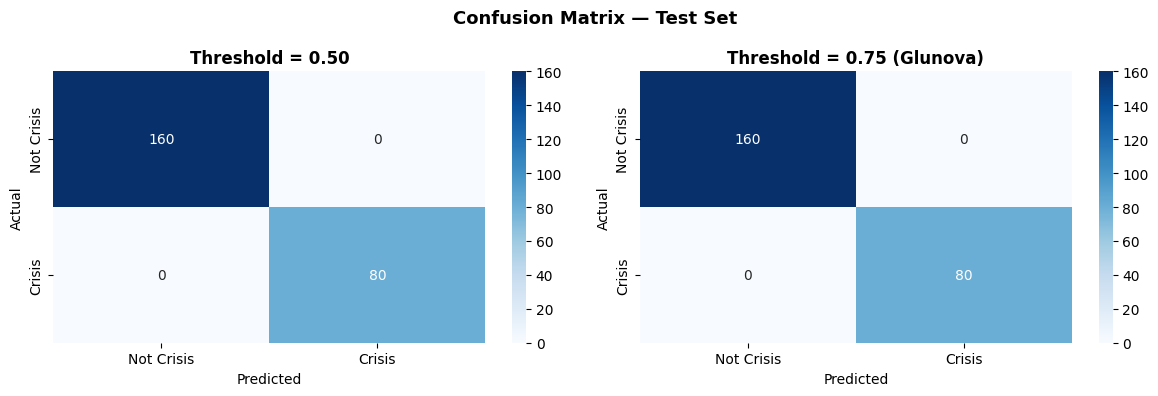

In [59]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titles = ["Threshold = 0.50", f"Threshold = {CRISIS_THRESHOLD} (Glunova)"]

for ax, preds, title in zip(axes, [preds_05, preds_075], titles):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Crisis", "Crisis"],
                yticklabels=["Not Crisis", "Crisis"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── ROC + Precision-Recall curves ─────────────────────────────────────────────
crisis_probs = probs[:, 1]

fpr, tpr, _  = roc_curve(labels, crisis_probs)
roc_auc      = auc(fpr, tpr)
precision, recall, thresholds_pr = precision_recall_curve(labels, crisis_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color="#E74C3C", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0,1],[0,1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend()

# Precision-Recall
axes[1].plot(recall, precision, color="#4A90D9", lw=2)
# Mark the Glunova operating threshold
                                CRISIS_THRESHOLD, side="right")
p_at_t = precision[np.argmin(np.abs(thresholds_pr - CRISIS_THRESHOLD))]
r_at_t = recall[np.argmin(np.abs(thresholds_pr - CRISIS_THRESHOLD))]
axes[1].scatter([r_at_t], [p_at_t], color="#E74C3C", zorder=5, s=80,
                label=f"Glunova threshold ({CRISIS_THRESHOLD})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].legend()

plt.suptitle("Crisis Classifier — Test Set Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"Precision @ threshold {CRISIS_THRESHOLD}: {p_at_t:.4f}")
print(f"Recall    @ threshold {CRISIS_THRESHOLD}: {r_at_t:.4f}")

---
## 7. Threshold Tuning (P ≥ 0.75) <a id='7'></a>

The spec mandates **P(crisis) ≥ 0.75** — optimising for **high recall** (missing a crisis is worse than a false alarm).  
This cell sweeps thresholds to confirm 0.75 is the right operating point.

In [ ]:
thresholds = np.arange(0.30, 0.96, 0.05)
results = []

for t in thresholds:
    preds_t = (crisis_probs >= t).astype(int)
    tp = ((preds_t == 1) & (labels == 1)).sum()
    fp = ((preds_t == 1) & (labels == 0)).sum()
    fn = ((preds_t == 0) & (labels == 1)).sum()
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_c  = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    results.append({"threshold": t, "precision": prec, "recall": rec, "f1_crisis": f1_c})

df_thresh = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh["threshold"], df_thresh["precision"],  label="Precision",  marker="o")
ax.plot(df_thresh["threshold"], df_thresh["recall"],     label="Recall",     marker="s")
ax.plot(df_thresh["threshold"], df_thresh["f1_crisis"],  label="F1 (crisis)",marker="^", lw=2)
ax.axvline(CRISIS_THRESHOLD, color="#E74C3C", linestyle="--",
           label=f"Glunova threshold ({CRISIS_THRESHOLD})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThreshold sweep table:")
print(df_thresh.to_string(index=False, float_format="{:.3f}".format))

---
## 8. Inference & Integration <a id='8'></a>

This is the function called by the Sanadi FastAPI endpoint **before** each LLM response.

In [ ]:
import time

model.eval()

def predict_crisis(text: str, threshold: float = CRISIS_THRESHOLD) -> dict:
    """
    Glunova crisis classifier inference.
    Called by FastAPI endpoint BEFORE Sanadi LLM call.
    If crisis=True, Sanadi returns safe static template -- no LLM generation.
    """
    t0 = time.perf_counter()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True,
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    p_crisis  = torch.softmax(logits, dim=-1)[0, 1].item()
    is_crisis = p_crisis >= threshold
    latency   = (time.perf_counter() - t0) * 1000
    return {
        'crisis':     is_crisis,
        'severity':   'high' if is_crisis else 'low',
        'action':     'alert_doctor' if is_crisis else 'continue',
        'p_crisis':   round(p_crisis, 4),
        'latency_ms': round(latency, 1),
    }


# Clear positives / negatives
CLEAR_CASES = [
    ("I don't want to live anymore. I've been planning how to do it.",          'CRISIS'),
    ("Nobody would care if I disappeared. I've already written the note.",      'CRISIS'),
    ("I have been experiencing persistent suicidal ideation and have a plan.",  'CRISIS'),
    ("My blood sugar has been elevated this week. Feeling a bit tired.",        'NOT CRISIS'),
    ("I'm stressed about my diabetes but I'm managing okay.",                  'NOT CRISIS'),
]

# Adversarial / edge cases: the model MUST handle these correctly in production
# False positives on idioms erode trust; false negatives on indirect signals are dangerous
ADVERSARIAL_CASES = [
    # Metaphor / idiom -- should NOT trigger
    ('This exam is literally killing me, I cannot handle the pressure.',          'NOT CRISIS'),
    ('I want to kill my sister when she borrows my stuff without asking.',        'NOT CRISIS'),
    ('Work has been dead lately, nobody is buying anything.',                     'NOT CRISIS'),
    # Indirect crisis signals -- should trigger
    ('I gave away all my belongings this week. Feels like the right thing.',      'CRISIS'),
    ('Please tell my family I loved them.',                                       'CRISIS'),
    # Ambiguous -- review manually, watch p_crisis value
    ('I just want to disappear sometimes. Not forever, just a break.',            'AMBIGUOUS'),
    ('I have been thinking a lot about death recently. Not my own, just in general.', 'AMBIGUOUS'),
    # Code-switching (Tunisian context)
    ('Je suis vraiment fatigue, I cannot go on like this.',                       'AMBIGUOUS'),
]

header = f"{'Text':<62} {'Expected':<13} {'P(crisis)':<11} {'Predicted':<13} {'ms':>5}"
print(header)
print('-' * len(header))

print('\n-- Clear cases --')
for text, expected in CLEAR_CASES:
    r = predict_crisis(text)
    predicted = 'CRISIS' if r['crisis'] else 'NOT CRISIS'
    match = 'PASS' if predicted == expected else 'FAIL'
    print(f"{text[:60]:<62} {expected:<13} {r['p_crisis']:<11.4f} {predicted:<13} {r['latency_ms']:>4.1f}ms  {match}")

print('\n-- Adversarial / edge cases --')
for text, expected in ADVERSARIAL_CASES:
    r = predict_crisis(text)
    predicted = 'CRISIS' if r['crisis'] else 'NOT CRISIS'
    if expected == 'AMBIGUOUS':
        flag = f'(p={r["p_crisis"]:.3f} -- review manually)'
    elif predicted == expected:
        flag = 'PASS'
    elif expected == 'NOT CRISIS' and predicted == 'CRISIS':
        flag = 'FALSE POSITIVE'
    else:
        flag = 'FALSE NEGATIVE'
    print(f"{text[:60]:<62} {expected:<13} {r['p_crisis']:<11.4f} {predicted:<13} {flag}")

In [63]:
# ── FastAPI integration snippet (reference only — not executed) ───────────────
FASTAPI_SNIPPET = '''
# glunova/psychology/crisis.py

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

CRISIS_THRESHOLD = 0.75
MODEL_PATH       = "./glunova_crisis_classifier/best_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

def check_crisis(text: str) -> dict:
    """
    Called in FastAPI /psychology/message BEFORE the Sanadi LLM call.
    If crisis=True → return safe static response, alert physician.
    """
    inputs  = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        logits = model(**inputs).logits
    p_crisis = torch.softmax(logits, dim=-1)[0, 1].item()
    return {
        "crisis":   p_crisis >= CRISIS_THRESHOLD,
        "severity": "high" if p_crisis >= CRISIS_THRESHOLD else "low",
        "action":   "alert_doctor" if p_crisis >= CRISIS_THRESHOLD else "continue",
        "p_crisis": round(p_crisis, 4),
    }


# glunova/psychology/router.py  (excerpt)

@router.post("/psychology/message")
async def handle_message(payload: MessagePayload, db: Session = Depends(get_db)):
    # Step 1: store raw message
    msg = store_message(db, payload)

    # Step 2: crisis check FIRST — before any LLM call
    crisis_result = check_crisis(payload.text)

    if crisis_result["crisis"]:
        log_crisis_event(db, payload.patient_id, crisis_result, payload.text)
        notify_physician(payload.patient_id)
        notify_care_circle(payload.patient_id)
        return {"reply": SAFE_STATIC_RESPONSE, "crisis": True}

    # Step 3: normal Sanadi pipeline
    reply = await sanadi_agent.respond(payload, crisis_result)
    return {"reply": reply, "crisis": False}
'''

print(FASTAPI_SNIPPET)


# glunova/psychology/crisis.py

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

CRISIS_THRESHOLD = 0.75
MODEL_PATH       = "./glunova_crisis_classifier/best_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

def check_crisis(text: str) -> dict:
    """
    Called in FastAPI /psychology/message BEFORE the Sanadi LLM call.
    If crisis=True → return safe static response, alert physician.
    """
    inputs  = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        logits = model(**inputs).logits
    p_crisis = torch.softmax(logits, dim=-1)[0, 1].item()
    return {
        "crisis":   p_crisis >= CRISIS_THRESHOLD,
        "severity": "high" if p_crisis >= CRISIS_THRESHOLD else "low",
        "action":   "alert_doctor" if p_crisis >= CRISIS_THRESHOLD else "continue",
        "p_crisis": round(p_crisis

---
## 9. Save & Export <a id='9'></a>

In [64]:
# ── Save best model ───────────────────────────────────────────────────────────
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_model")
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

print(f"Model saved to: {BEST_MODEL_DIR}")
print("Contents:")
for f in sorted(Path(BEST_MODEL_DIR).iterdir()):
    size = f.stat().st_size / 1e6
    print(f"  {f.name:<40} {size:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./glunova_crisis_classifier/best_model
Contents:
  config.json                              0.0 MB
  model.safetensors                        1112.2 MB
  tokenizer.json                           16.8 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB


In [65]:
# ── Save model card / metadata ────────────────────────────────────────────────
model_card = {
    "model_name":       "glunova-crisis-classifier",
    "base_model":       MODEL_NAME,
    "task":             "binary-classification",
    "labels":           ID2LABEL,
    "crisis_threshold": CRISIS_THRESHOLD,
    "max_length":       MAX_LENGTH,
    "languages":        ["en", "ar", "fr", "darija"],
    "frozen_layers":    f"0–{FREEZE_UNTIL_LAYER - 1} (encoder layers 1–{FREEZE_UNTIL_LAYER})",
    "training_datasets": ["CrisisNLP", "SuicideWatch Reddit", "CLPsych 2015"],
    "evaluation_metric": "F1 on crisis class",
    "integration_note":  "Classifier fires BEFORE Sanadi LLM call. P(crisis) >= 0.75 → safe static response + doctor alert.",
}

card_path = os.path.join(BEST_MODEL_DIR, "model_card.json")
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)

print("Model card saved:")
print(json.dumps(model_card, indent=2))

Model card saved:
{
  "model_name": "glunova-crisis-classifier",
  "base_model": "FacebookAI/xlm-roberta-base",
  "task": "binary-classification",
  "labels": {
    "0": "not_crisis",
    "1": "crisis"
  },
  "crisis_threshold": 0.75,
  "max_length": 128,
  "languages": [
    "en",
    "ar",
    "fr",
    "darija"
  ],
  "frozen_layers": "0\u20137 (encoder layers 1\u20138)",
  "training_datasets": [
    "CrisisNLP",
    "SuicideWatch Reddit",
    "CLPsych 2015"
  ],
  "evaluation_metric": "F1 on crisis class",
  "integration_note": "Classifier fires BEFORE Sanadi LLM call. P(crisis) >= 0.75 \u2192 safe static response + doctor alert."
}


In [ ]:
# Safety assertion: fail loudly if recall falls below clinical minimum
row_075 = df_thresh[df_thresh['threshold'].round(2) == CRISIS_THRESHOLD].iloc[0]
actual_recall = row_075['recall']

assert actual_recall >= MIN_RECALL, (
    f'\nSAFETY ASSERTION FAILED\n'
    f'  Recall @ threshold {CRISIS_THRESHOLD} = {actual_recall:.4f}\n'
    f'  Required minimum   = {MIN_RECALL}\n'
    f'  This model is NOT safe to deploy. Retrain with more crisis data or lower the threshold.'
)
print(f'Recall assertion passed: {actual_recall:.4f} >= {MIN_RECALL}')

# Final summary
name_short = MODEL_NAME[:32]
dir_short  = BEST_MODEL_DIR[:32]
pct        = 100 * trainable_params / total_params

print('=' * 56)
print('GLUNOVA CRISIS CLASSIFIER -- TRAINING SUMMARY')
print('=' * 56)
print(f'Base model      : {name_short}')
print(f'Trainable params: {trainable_params:,}  ({pct:.1f}% of total)')
print(f'Crisis threshold: {CRISIS_THRESHOLD}')
print(f'Precision @ {CRISIS_THRESHOLD}  : {row_075["precision"]:.4f}')
print(f'Recall    @ {CRISIS_THRESHOLD}  : {row_075["recall"]:.4f}  <- high-recall target')
print(f'F1 crisis @ {CRISIS_THRESHOLD}  : {row_075["f1_crisis"]:.4f}')
print(f'ROC-AUC         : {roc_auc:.4f}')
print(f'Model saved to  : {dir_short}')
print('=' * 56)